# DA Mini Project
* 주제 : 온라인 학습 플랫폼 사용자 행동 패턴 분석
* 개요 :
```
이번 프로젝트는 학습 서비스를 이용하는 독자들 중 누가 서비스 구독을 연장할지 예측하기 위한 사전 파악에 초점을 맞추고 있습니다. 우리의 목표는 유저들의 학습 습관, 선호도, 이용 행태 등 다양한 측면을 면밀히 분석하는 것입니다.


이를 위해, 우리는 유저들의 학습 패턴, 서비스 이용 시간, 콘텐츠에 대한 반응, 그리고 이들이 얼마나 자주 서비스를 이용하는지 등 다양한 데이터를 수집하고 분석할 계획입니다. 이 데이터는 유저들이 서비스에 얼마나 만족하고 있는지, 어떤 요소들이 그들의 구독 결정에 영향을 미치는지 이해하는 데 중요한 역할을 할 것입니다.
```
* 데이터셋 : mini.csv
    * 메타데이터
        * user_id: 사용자의 고유 식별자
        * subscription_duration: 사용자가 서비스에 가입한 기간 (월)
        * recent_login_time: 사용자가 마지막으로 로그인한 시간 (일)
        * average_login_time:  사용자의 일반적인 로그인 시간
        * average_time_per_learning_session: 각 학습 세션에 소요된 평균 시간 (분)
        * monthly_active_learning_days: 월간 활동적인 학습 일수
        * total_completed_courses: 완료한 총 코스 수
        * recent_learning_achievement: 최근 학습 성취도
        * abandoned_learning_sessions: 중단된 학습 세션 수
        * community_engagement_level: 커뮤니티 참여도
        * preferred_difficulty_level: 선호하는 난이도
        * subscription_type: 구독 유형
        * customer_inquiry_history: 고객 문의 이력
        * payment_pattern : 사용자의 지난 3개월 간의 결제 패턴을 10진수로 표현한 값.
          - 7: 3개월 모두 결제함
          - 6: 첫 2개월은 결제했으나 마지막 달에는 결제하지 않음
          - 5: 첫 달과 마지막 달에 결제함
          - 4: 첫 달에만 결제함
          - 3: 마지막 2개월에 결제함
          - 2: 가운데 달에만 결제함
          - 1: 마지막 달에만 결제함
          - 0: 3개월 동안 결제하지 않음
        * target: 사용자가 다음 달에도 구독을 계속할지 (1) 또는 취소할지 (0)를 나타냄
-----

## 1. 데이터 이해

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import koreanize_matplotlib
import seaborn as sns

In [2]:
pip install seaborn --upgrade

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip show seaborn

Name: seaborn
Version: 0.13.2
Summary: Statistical data visualization
Home-page: 
Author: 
Author-email: Michael Waskom <mwaskom@gmail.com>
License: 
Location: C:\Users\ai3_jiahn\anaconda3\Lib\site-packages
Requires: matplotlib, numpy, pandas
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [4]:
access_data = pd.read_table('data/mini.csv',sep=',')

In [5]:
access_data.tail()

,user_id,subscription_duration,recent_login_time,average_login_time,average_time_per_learning_session,monthly_active_learning_days,total_completed_courses,recent_learning_achievement,abandoned_learning_sessions,community_engagement_level,preferred_difficulty_level,subscription_type,customer_inquiry_history,payment_pattern,target
9995,ae6b76bc,22,29,14.727623,84.053558,18,16,64.966803,2,5,Low,Premium,1,1,1
9996,24588752,10,11,19.374054,45.464833,9,8,82.750244,3,3,Medium,Basic,2,7,1
9997,e4622a54,7,27,18.240978,127.302411,24,14,81.567839,3,5,High,Basic,1,6,1
9998,e07fbad9,11,7,18.783800,5.297234,10,10,89.885656,4,5,Low,Basic,2,0,1
9999,e12dcb55,10,5,13.073230,28.120031,3,13,64.811297,4,5,Low,Premium,0,3,0


In [6]:
access_data.info() # 결측치, 데이터 타입 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   user_id                            10000 non-null  object 
 1   subscription_duration              10000 non-null  int64  
 2   recent_login_time                  10000 non-null  int64  
 3   average_login_time                 10000 non-null  float64
 4   average_time_per_learning_session  10000 non-null  float64
 5   monthly_active_learning_days       10000 non-null  int64  
 6   total_completed_courses            10000 non-null  int64  
 7   recent_learning_achievement        10000 non-null  float64
 8   abandoned_learning_sessions        10000 non-null  int64  
 9   community_engagement_level         10000 non-null  int64  
 10  preferred_difficulty_level         10000 non-null  object 
 11  subscription_type                  10000 non-null  obje

In [7]:
a = access_data.describe(include='all') # 데이터 통계보기
describe_df = a.transpose() # 보기 편하도록 행열 바꿈
describe_df

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,10000,10000,b919c29d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subscription_duration,10000.0,NaN,NaN,NaN,11.8974,6.600896,1.0,6.0,12.0,18.0,23.0
recent_login_time,10000.0,NaN,NaN,NaN,15.0132,8.362573,1.0,8.0,15.0,22.0,29.0
average_login_time,10000.0,NaN,NaN,NaN,14.994076,3.001869,2.366189,13.025597,14.979228,16.99534,26.99849
average_time_per_learning_session,10000.0,NaN,NaN,NaN,54.91772,56.02431,0.011515,15.276611,37.578818,75.5842,503.372616
monthly_active_learning_days,10000.0,NaN,NaN,NaN,12.5454,6.932239,1.0,7.0,13.0,19.0,24.0
total_completed_courses,10000.0,NaN,NaN,NaN,12.2275,3.634125,1.0,10.0,12.0,15.0,27.0
recent_learning_achievement,10000.0,NaN,NaN,NaN,75.029513,9.968529,35.941755,68.278054,75.126061,81.718976,112.643828
abandoned_learning_sessions,10000.0,NaN,NaN,NaN,3.0436,1.755052,0.0,2.0,3.0,4.0,12.0
community_engagement_level,10000.0,NaN,NaN,NaN,3.8861,1.262175,1.0,3.0,4.0,5.0,5.0


In [8]:
columns = describe_df.loc[:, ['mean', 'std']]  # 평균과 표준편차만 확인
columns

,mean,std
user_id,NaN,NaN
subscription_duration,11.8974,6.600896
recent_login_time,15.0132,8.362573
average_login_time,14.994076,3.001869
average_time_per_learning_session,54.91772,56.02431
monthly_active_learning_days,12.5454,6.932239
total_completed_courses,12.2275,3.634125
recent_learning_achievement,75.029513,9.968529
abandoned_learning_sessions,3.0436,1.755052
community_engagement_level,3.8861,1.262175


### 결과
 #### 1-1) 데이터 정의
* 메타데이터의 각 항목에서 뜻하는 바가 명확하지 않다고 생각해, 다음과 같이 정의 및 정리해보았습니다.
  
    * 세션보다 코스가 큰 개념이며 코스 안에 여러 개의 세션이 있다.
    * average_login_time 사용자의 일반적인 로그인 시간은 "누적 로그인 시간"으로 정의한다.
        * 평소 접속하는 시간 vs 평균적인 체류시간 vs 누적 로그인 시간
        * 1번이라기엔 데이터 타입이 실수이다. 시계열 데이터로 바꿔 극복할 수 있으나, 최대값이 26.99849이다.
        * 평균적인 체류시간이 평균 약 15시간인 것은 신뢰하기 어렵다.
    * 최근 학습 성취도의 산정 근거는 알 수 없으므로 별도의 데이터로 가정한다.
    * target 은 예측치인지, 설문을 통한 정보인지 알 수 없으므로 이미 구독이 완료된 절대적인 데이터로 가정한다.
    * community_engagement_level 커뮤니티 참여도는 Lv.1 에서 Lv.5까지 이다.
    * preferred_difficulty_level 선호하는 난이도는 Low - Medium - High 로 나누어진다.
    * subscription_type 구독 유형은 Basic, Premium 2종류 이다.



 #### 1-2) 데이터 요약
* 1만개의 데이터를 가지고 있고, 결측치는 없습니다.
* 사용자는 평균적으로 약 12개월간 서비스를 구독합니다.
* 한 개의 세션을 완료하는데 평균적으로 약 1시간 정도 소요됩니다.
* 평균적으로 한 달에 약 12일간 학습하고 평균 12개의 코스를 완료합니다.
* 평균적인 학습 성취도는 약 75%, 편차는 10% 가량으로 크지않은 편입니다.

------

## 2. 상관분석

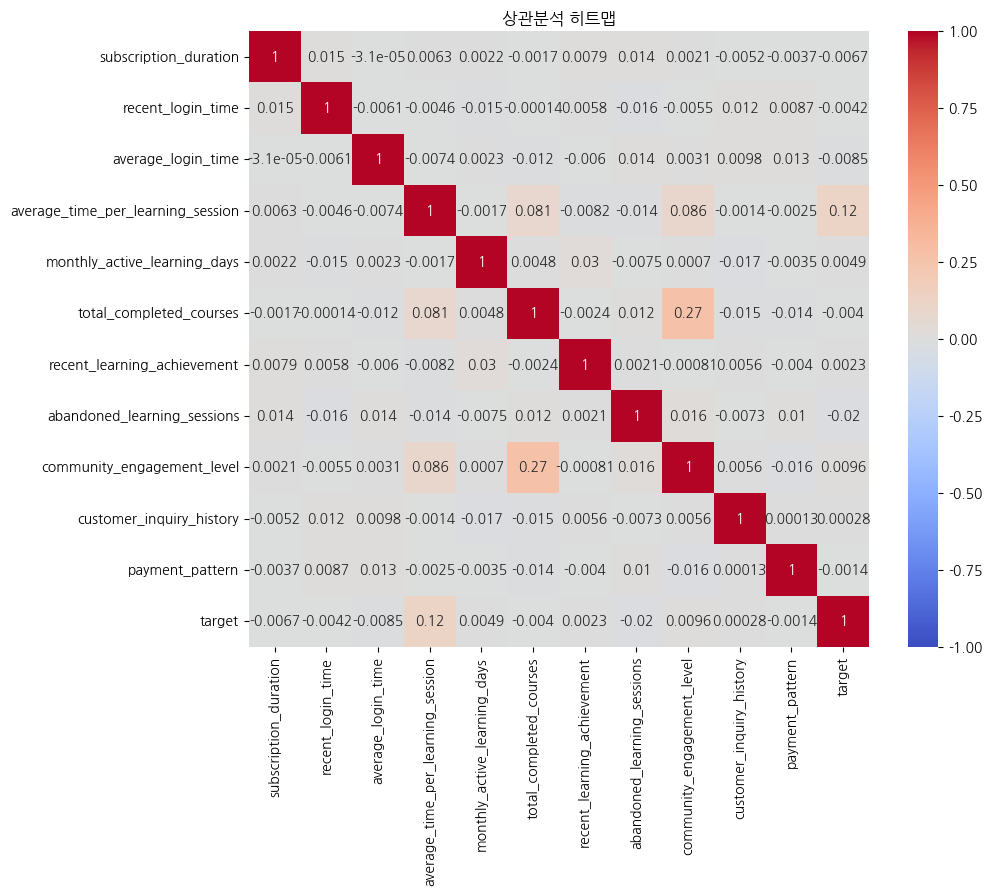

In [9]:
access_data2 = access_data.drop(columns=['user_id','preferred_difficulty_level','subscription_type'])
correlation_matrix = access_data2.corr()
correlation_matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('상관분석 히트맵')
plt.show()

### 결과
* total_completed_courses와 community_engagement_level 의 상관관계가 가장 높습니다.
    * 이는 내부에서 활발하게 소통하는 것과 학습 코스를 완료하는 것이 상관이 있다는 것을 의미합니다.
* average_time_per_learning_session과 target의의 상관관계가 2번째로 높습니다.
    * 이는 각 학습 세션에 소요된 평균 시간과 익월에 구독을 계속하는 것이 상관이 있다는 것을 의미합니다.
* 또한 average_time_per_learning_session 은 total_completed_courses, community_engagement_level 과의 상관관계도 높습니다.



#### [상관관계] total_completed_courses ↔ community_engagement_level ↔ average_time_per_learning_session ↔ target
완료한 총 코스 수 ↔ 커뮤니티 참여도 ↔ 각 학습 세션에 소요된 평균 시간 (분) ↔ 익월 구독 여부



그림으로 표현하면 아래와 같습니다.

![nn](슬라이드1.png)

------

 ## 3. 문제인식, 
 

 ## 3. 가설 세우기
    가설 1. monthly_active_learning_days와 community_engagement_level이 높은 사람들은 구독을 연장할 가능성이 높을 것이다.
    가설 2. 지난 3개월 동안 모두 결제한 사람은 이어서 구독할 가능성이 높을 것이다.